In [1]:
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import lightgbm as lgb
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.metrics import ndcg_score

In [3]:
DATA_DIR = "/content/drive/MyDrive/Colab Notebooks"

train_data = pd.read_parquet(f"{DATA_DIR}/train_fe.parquet")
val_data = pd.read_parquet(f"{DATA_DIR}/val_fe.parquet")
test_data = pd.read_parquet(f"{DATA_DIR}/test_fe.parquet")

In [4]:
train_data.head()

,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,...,ump,total_fee,per_fee,score2ma,score1d2,count_window,prop_id_1cnt,srch_destination_id_1cnt,prop_location_score2_1cnt,relevance
0,1,2013-04-04 08:32:15,12,187,0.0,0.0,219,893,3,3.5,...,36.404930,104.769997,26.192499,-0.895381,0.015512,1000,1237,27173,496362,0
1,1,2013-04-04 08:32:15,12,187,0.0,0.0,219,10404,4,4.0,...,-17.806961,170.740005,42.685001,-0.304593,0.006818,1000,1127,27173,492804,0
2,1,2013-04-04 08:32:15,12,187,0.0,0.0,219,21315,3,4.5,...,-42.797379,179.800003,44.950001,-0.500841,0.011181,1000,1101,27173,499551,0
3,1,2013-04-04 08:32:15,12,187,0.0,0.0,219,27348,2,4.0,...,-522.129639,602.770020,150.692505,-0.255531,0.004452,1000,926,27173,492804,0
4,1,2013-04-04 08:32:15,12,187,0.0,0.0,219,29604,4,3.5,...,-5.200516,143.580002,35.895000,-2.536914,0.047044,1000,1336,27173,495382,0


In [5]:
# Sort all datasets by search ID
# (all hotels belonging to the same search to be clustered together so it can compare them against each other)
train_data = train_data.sort_values('srch_id')
val_data = val_data.sort_values('srch_id')
test_data = test_data.sort_values('srch_id')

# Calculate the group sizes
# count exactly how many rows belong to each srch_id. So LightGBM knows where one search ends and the next begins.
train_groups = train_data.groupby('srch_id').size().values
val_groups = val_data.groupby('srch_id').size().values

print("Train group sizes:", train_groups)
print("Validation group sizes:", val_groups)

Train group sizes: [28 32  5 ... 24 28  6]
Validation group sizes: [28 29 34 ... 16  6 15]


In [6]:
# Convert categorical features to category dtype and fill missing values with -1
categorical_features = ['site_id', 'visitor_location_country_id', 'prop_country_id', 'srch_destination_id']

for col in categorical_features:
    if col in train_data.columns and col in val_data.columns and col in test_data.columns:
        train_data[col] = train_data[col].astype(float).fillna(-1).astype(int).astype('category')
        val_data[col] = val_data[col].astype(float).fillna(-1).astype(int).astype('category')
        test_data[col] = test_data[col].astype(float).fillna(-1).astype(int).astype('category')

In [7]:
# Define features and target
features = [col for col in train_data.columns if col not in ['srch_id', 'prop_id', 'relevance',
                                                             'date_time', 'click_bool', 'booking_bool',
                                                             'position', 'gross_bookings_usd']]
X_train = train_data[features]
y_train = train_data['relevance']
X_val = val_data[features]
y_val = val_data['relevance']
X_test = test_data[features]

In [8]:
# Define the hyperparameter search space
param_grid = {
    'num_leaves': [20, 31, 63],
    'learning_rate': [0.05, 0.1, 0.2],
    'n_estimators': [100, 500, 1000],
}

n_iterations = 10
n_splits = 5

best_params = {}
best_cv_score = 0

X_full = X_train.copy()
y_full = y_train.copy()
groups_full = train_data['srch_id'].values

print("Starting hyperparameter tuning with GroupKFold cross-validation...")

for i in range(n_iterations):
    params = {key: np.random.choice(values) for key, values in param_grid.items()}
    print(f"Iteration {i+1}/{n_iterations}, Testing parameters: {params}")

    gkf = GroupKFold(n_splits=n_splits)
    fold_scores = []

    for train_idx, val_idx in gkf.split(X_full, y_full, groups=groups_full):
        X_train_fold, y_train_fold = X_full.iloc[train_idx], y_full.iloc[train_idx]
        X_val_fold, y_val_fold = X_full.iloc[val_idx], y_full.iloc[val_idx]

        train_fold_groups = X_train_fold.groupby(groups_full[train_idx]).size().values
        val_fold_groups = X_val_fold.groupby(groups_full[val_idx]).size().values

        ranker = lgb.LGBMRanker(objective='lambdarank', metric='ndcg', eval_at=[5], random_state=42, **params)
        ranker.fit(X_train_fold, y_train_fold, group=train_fold_groups,
            eval_set=[(X_val_fold, y_val_fold)],
            eval_group=[val_fold_groups],
            callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]
        )

        best_iteration = ranker.best_iteration_
        fold_score = ranker.best_score_['valid_0']['ndcg@5']
        fold_scores.append(fold_score)

    avg_score = np.mean(fold_scores)
    print(f"Average NDCG@5 for iteration {i+1}: {avg_score:.4f}")
    if avg_score > best_cv_score:
        best_cv_score = avg_score
        best_params = params
        print(f"New best parameters found: {best_params} with NDCG@5: {best_cv_score:.4f}")

print(f"Best hyperparameters: {best_params} with NDCG@5: {best_cv_score:.4f}")

Starting hyperparameter tuning with GroupKFold cross-validation...
Iteration 1/10, Testing parameters: {'num_leaves': np.int64(20), 'learning_rate': np.float64(0.1), 'n_estimators': np.int64(100)}


/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.332713 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14937
[LightGBM] [Info] Number of data points in the train set: 3372456, number of used features: 55


/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.341609 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14987
[LightGBM] [Info] Number of data points in the train set: 3372456, number of used features: 55


...

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.333230 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14926
[LightGBM] [Info] Number of data points in the train set: 3372456, number of used features: 55


/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.226222 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14977
[LightGBM] [Info] Number of data points in the train set: 3372456, number of used features: 55


/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.277435 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14996
[LightGBM] [Info] Number of data points in the train set: 3372452, number of used features: 55
Average NDCG@5 for iteration 10: 0.3875
Best hyperparameters: {'num_leaves': np.int64(20), 'learning_rate': np.float64(0.1), 'n_estimators': np.int64(1000)} with NDCG@5: 0.3879


In [9]:
best_params = {'num_leaves': np.int64(31), 'learning_rate': np.float64(0.1), 'n_estimators': np.int64(500)}
#Early stopping, best iteration is: [309]	valid_0's ndcg@5: 0.380935 with all features

In [10]:
# Initialize the LGBMRanker with the specified parameters
ranker = lgb.LGBMRanker(
    objective='lambdarank',
    metric='ndcg',
    eval_at=[5],
    random_state=42,
    importance_type='gain',
    **best_params
)

# Fit the model with early stopping
ranker.fit(
    X_train, y_train,
    group=train_groups,
    eval_set=[(X_val, y_val)],
    eval_group=[val_groups],
    callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=50)]
)

/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.330409 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14909
[LightGBM] [Info] Number of data points in the train set: 4215569, number of used features: 55
Training until validation scores don't improve for 100 rounds
[50]	valid_0's ndcg@5: 0.385682
[100]	valid_0's ndcg@5: 0.393421
[150]	valid_0's ndcg@5: 0.396285
[200]	valid_0's ndcg@5: 0.397732
[250]	valid_0's ndcg@5: 0.397092
[300]	valid_0's ndcg@5: 0.397049
Early stopping, best iteration is:
[225]	valid_0's ndcg@5: 0.398277


LGBMRanker(eval_at=[5], importance_type='gain', learning_rate=np.float64(0.1),
           metric='ndcg', n_estimators=np.int64(500), num_leaves=np.int64(31),
           objective='lambdarank', random_state=42)

In [11]:
# After finding the best hyperparameters, we can train the final model on the combined training and validation data
X_full = pd.concat([X_train, X_val], ignore_index=True)
y_full = pd.concat([y_train, y_val], ignore_index=True)

groups_full = np.concatenate([train_groups, val_groups])

final_ranker = lgb.LGBMRanker(
    objective='lambdarank',
    metric='ndcg',
    eval_at=[5],
    random_state=42,
    importance_type='gain',
    n_estimators=350,
    num_leaves=31,
    learning_rate=0.1
)

print("Training final model on combined training and validation data...")
final_ranker.fit(
    X_full, y_full,
    group=groups_full,
    callbacks=[lgb.log_evaluation(period=100)]
)

Training final model on combined training and validation data...


/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.462714 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7743
[LightGBM] [Info] Number of data points in the train set: 4958347, number of used features: 55


LGBMRanker(eval_at=[5], importance_type='gain', metric='ndcg', n_estimators=350,
           objective='lambdarank', random_state=42)

In [12]:
# Make predictions on the test set
X_test = test_data[features].copy()

# Force X_test to adopt the exact same categorical structure as X_full
for col in categorical_features:
    if col in X_test.columns:
        X_test[col] = X_test[col].astype(X_full[col].dtype)

test_data['predicted_score'] = final_ranker.predict(X_test)

# Sort the test data by Search ID, then by the predicted score descending
# This puts the highest scored hotels at the top for each search
test_predictions = test_data.sort_values(['srch_id', 'predicted_score'], ascending=[True, False])

# Keep only the necessary columns and rename them to match the required format[cite: 2]
submission = test_predictions[['srch_id', 'prop_id']].copy()

# Save to CSV without the index
submission.to_csv(f'{DATA_DIR}/submission_lightgbm.csv', index=False)
print("Submission saved to submission_lightgbm.csv!")

/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


Submission saved to submission_lightgbm.csv!


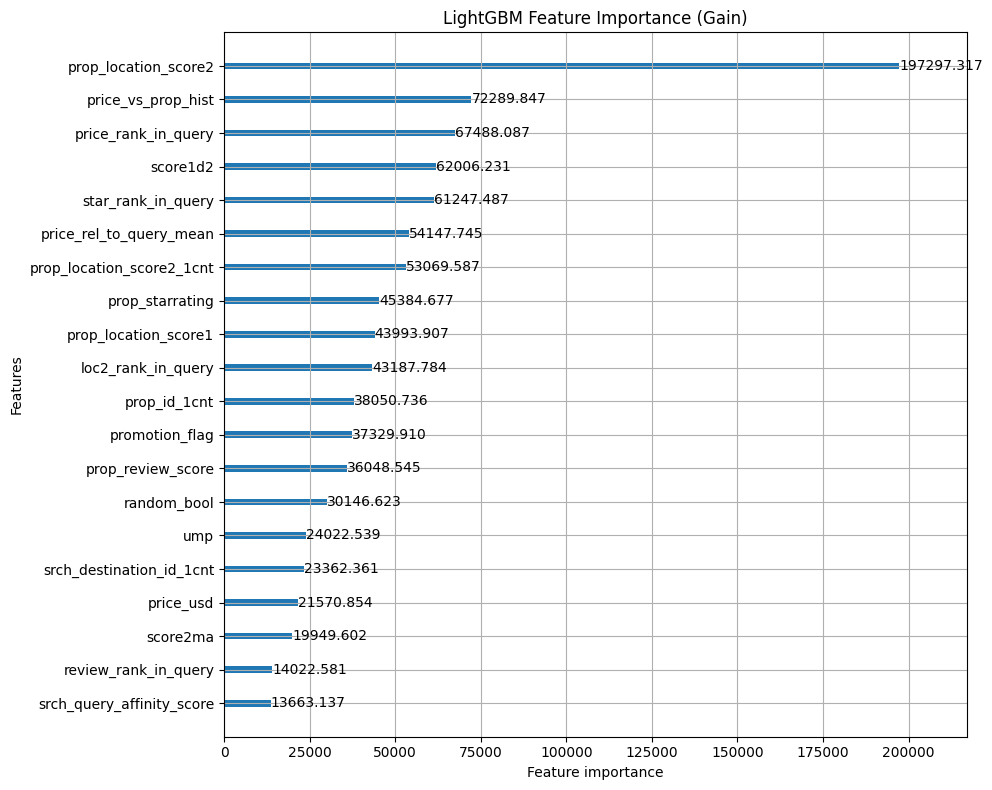

In [13]:
import matplotlib.pyplot as plt

# Tell LightGBM to plot the top 20 most important features
lgb.plot_importance(final_ranker, max_num_features=20, figsize=(10, 8), importance_type='gain')
plt.title("LightGBM Feature Importance (Gain)")
# save the plot as a pdf
plt.tight_layout()
plt.savefig(f"{DATA_DIR}/feature_importance.pdf")
plt.show()